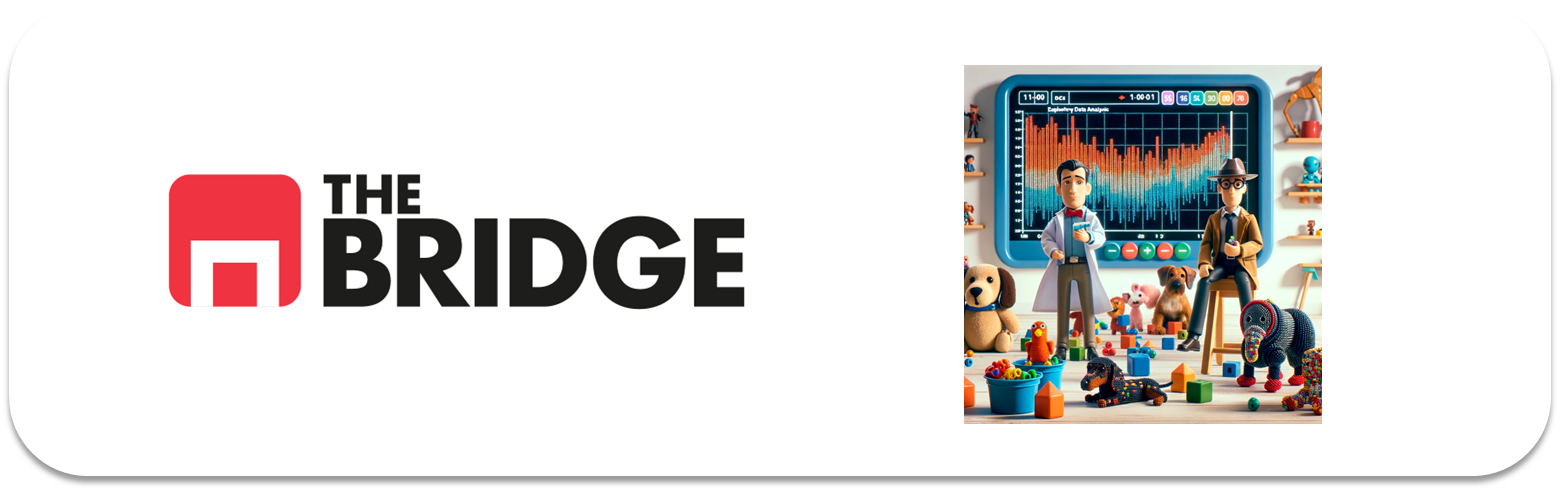

## PRACTICA OBLIGATORIA: **Análisis Multivariante**

* La práctica obligatoria de esta unidad consiste en completar el análisis del dataset del Titanic, dirigido por una serie de preguntas, y de terminar de analizar algunos aspectos del dataset de viajes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0


Importa los paquetes y módulos que necesites a lo largo del notebook

In [2]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from bootcampviztools import plot_categorical_numerical_relationship, plot_combined_graphs, \
    pinta_distribucion_categoricas, plot_grouped_boxplots, plot_categorical_relationship_fin, plot_grouped_histograms, \
        grafico_dispersion_con_correlacion

## #1: Titanic

### #1.1

Carga en un dataframe el dataset del titanic, que está en la ruta "./data/titanic.csv".

In [3]:
df = pd.read_csv("./data/titanic.csv")

### #1.2

Deshazte de las columnas "deck", "survived", "pclass" y "embarked" porque no las emplearemos, la primera por su cantidad de nulos y el resto porque son variantes de otras que ya existen y cuyos valores resultan más expresivos a la hora de hacer un análisis. 

In [4]:
df = df.drop(columns=["deck", "survived", "pclass" , "embarked"] )
df

,sex,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive,alone
0,male,22.0,1,0,7.2500,Third,man,True,Southampton,no,False
1,female,38.0,1,0,71.2833,First,woman,False,Cherbourg,yes,False
2,female,26.0,0,0,7.9250,Third,woman,False,Southampton,yes,True
3,female,35.0,1,0,53.1000,First,woman,False,Southampton,yes,False
4,male,35.0,0,0,8.0500,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...
886,male,27.0,0,0,13.0000,Second,man,True,Southampton,no,True
887,female,19.0,0,0,30.0000,First,woman,False,Southampton,yes,True
888,female,NaN,1,2,23.4500,Third,woman,False,Southampton,no,False
889,male,26.0,0,0,30.0000,First,man,True,Cherbourg,yes,True


### #1.3

Suma las columnas "parch" y "sibsp" para tener el número de parientes de cada pasajero, guarda el resultado en otra columna "family_members", luego deshazte de "parch" y "sibsp"

In [5]:
df["family_members"] = df["parch"] + df["sibsp"]
df

,sex,age,sibsp,parch,fare,class,who,adult_male,embark_town,alive,alone,family_members
0,male,22.0,1,0,7.2500,Third,man,True,Southampton,no,False,1
1,female,38.0,1,0,71.2833,First,woman,False,Cherbourg,yes,False,1
2,female,26.0,0,0,7.9250,Third,woman,False,Southampton,yes,True,0
3,female,35.0,1,0,53.1000,First,woman,False,Southampton,yes,False,1
4,male,35.0,0,0,8.0500,Third,man,True,Southampton,no,True,0
...,...,...,...,...,...,...,...,...,...,...,...,...
886,male,27.0,0,0,13.0000,Second,man,True,Southampton,no,True,0
887,female,19.0,0,0,30.0000,First,woman,False,Southampton,yes,True,0
888,female,NaN,1,2,23.4500,Third,woman,False,Southampton,no,False,3
889,male,26.0,0,0,30.0000,First,man,True,Cherbourg,yes,True,0


In [8]:
df = df.drop(columns= ["parch","sibsp"])
df

,sex,age,fare,class,who,adult_male,embark_town,alive,alone,family_members
0,male,22.0,7.2500,Third,man,True,Southampton,no,False,1
1,female,38.0,71.2833,First,woman,False,Cherbourg,yes,False,1
2,female,26.0,7.9250,Third,woman,False,Southampton,yes,True,0
3,female,35.0,53.1000,First,woman,False,Southampton,yes,False,1
4,male,35.0,8.0500,Third,man,True,Southampton,no,True,0
...,...,...,...,...,...,...,...,...,...,...
886,male,27.0,13.0000,Second,man,True,Southampton,no,True,0
887,female,19.0,30.0000,First,woman,False,Southampton,yes,True,0
888,female,NaN,23.4500,Third,woman,False,Southampton,no,False,3
889,male,26.0,30.0000,First,man,True,Cherbourg,yes,True,0


### #1.4

Imputa la moda a los valores nulos de "embark_town"

In [13]:

df["embark_town"].fillna(df["embark_town"].mode()[0], inplace = True)


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sex             891 non-null    object 
 1   age             714 non-null    float64
 2   fare            891 non-null    float64
 3   class           891 non-null    object 
 4   who             891 non-null    object 
 5   adult_male      891 non-null    bool   
 6   embark_town     891 non-null    object 
 7   alive           891 non-null    object 
 8   alone           891 non-null    bool   
 9   family_members  891 non-null    int64  
dtypes: bool(2), float64(2), int64(1), object(5)
memory usage: 57.6+ KB


### #1.5

Imputa la media a los valores faltantes de "age", si quieres puedes hacer algo más preciso (por ejemplo considerando además la columna "who")

In [16]:
df["age"].fillna(df.groupby(["class","who"])["age"].transform("mean"), inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sex             891 non-null    object 
 1   age             891 non-null    float64
 2   fare            891 non-null    float64
 3   class           891 non-null    object 
 4   who             891 non-null    object 
 5   adult_male      891 non-null    bool   
 6   embark_town     891 non-null    object 
 7   alive           891 non-null    object 
 8   alone           891 non-null    bool   
 9   family_members  891 non-null    int64  
dtypes: bool(2), float64(2), int64(1), object(5)
memory usage: 57.6+ KB


C:\Users\javie\AppData\Local\Temp\ipykernel_22492\2450193125.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["age"].fillna(df.groupby(["class","who"])["age"].transform("mean"), inplace=True)


### #1.6

Realiza los análisis bivariantes o multivariantes que necesites, así como los test de hipótesis necesarios para contestar a las siguientes preguntas. Nota: utiliza la variable "alive" para saber si un pasajero sobrevivió o no:

1. En términos absolutos, ¿sobrevivieron más hombres, mujeres o niños? ¿Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre el sexo y la supervivencia en el Titanic?¿Y entre ser adulto o ser niño?

2. En términos absolutos, ¿de que clase sobrevivieron más pasajeros?¿ Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre la clase en la que se viajaba y la supervivencia?

3. ¿De qué ciudad sobrevivieron más personas?¿Y porcentualmente de que ciudad sobrevivieron más personas? ¿Hay alguna relación estadística significativa entre haber embarcado en una de las tres ciudades y haber sobrevivido o fallecido?

4. ¿Qué relación hay entre el precio del pasaje y la supervivencia/fallecimiento?

5. Existen pasajero que no pagaron el billete, ¿podrías explicar por qué? ¿Qué ocurrió con la persona que más dinero se dejó?

6. Existe alguna relación entre el dinero pagado, la ciudad de embarque y la superviviencia/fallecimiento. No necesitas aplicar ningún test, muestralo numérica o visualmente.

7. Ahondando en la relación entre sobrevivir o fallecer, la clase en la que se viajó y la edad de los pasajeros. ¿Qué agrupación de las dos variables (clase y edad) sobrevivió más en términos absolutos y en términos relativos?

8. Finalmente, muestra las posibles relaciones entre edad, coste del billete y supervivencia/fallecimiento. ¿Qué puedes decir al respecto?

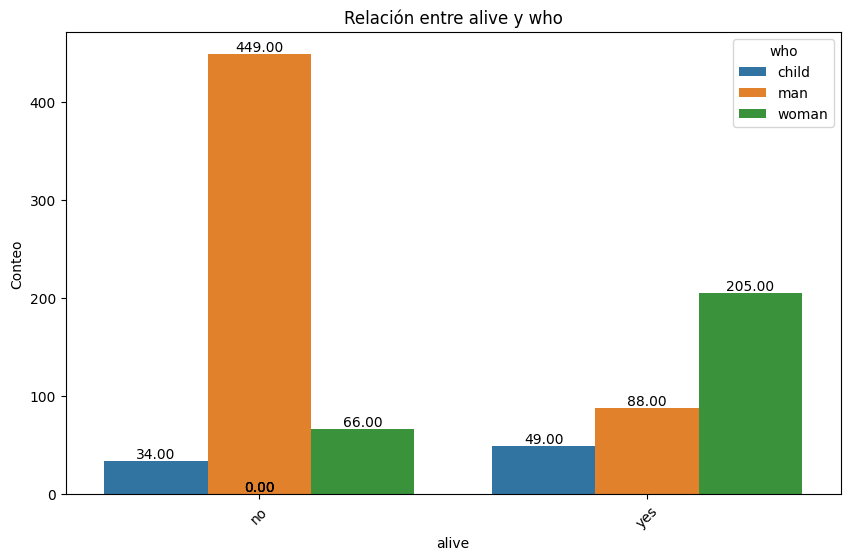

In [17]:
plot_categorical_relationship_fin(df,"alive","who", show_values= True)

In [18]:
# de forma absoluta sobrevivieron más mujeres

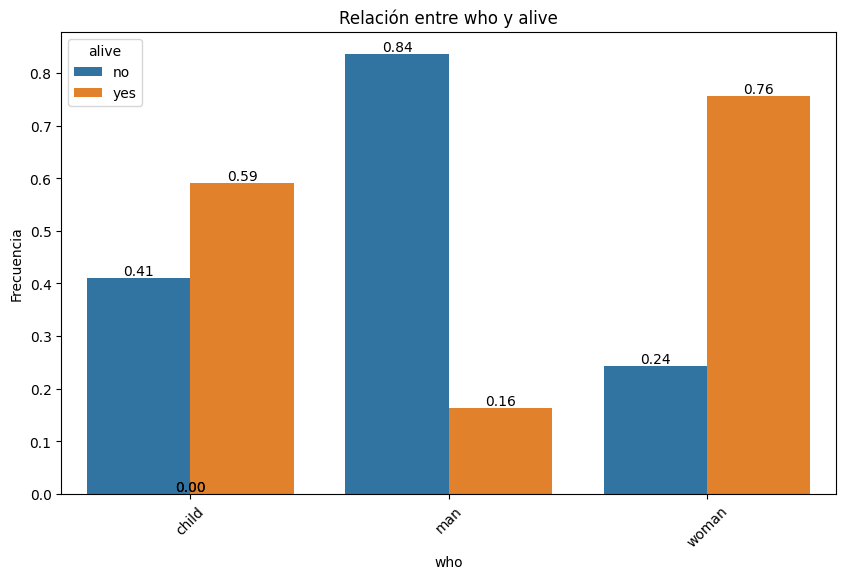

In [21]:
plot_categorical_relationship_fin(df,"who","alive", relative_freq=True, show_values= True)

In [23]:
#de forma relativa, también mujeres
from scipy.stats import chi2_contingency

In [25]:
tabla_contingencia = pd.crosstab(df['sex'], df['alive'])
chi2, p, dof, expected = chi2_contingency(tabla_contingencia)

print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)
print("Grados de Libertad:", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)

Valor Chi-Cuadrado: 260.71702016732104
P-Value: 1.1973570627755645e-58
Grados de Libertad: 1
Tabla de Frecuencias Esperadas:
 [[193.47474747 120.52525253]
 [355.52525253 221.47474747]]


In [26]:
# confirmamos que si existe una relación estdísticamente significativa entre sobrevivir siendo mujeres y hombres

In [30]:
df["niño"]=df["who"]=="child"
tabla_contingencia = pd.crosstab(df['niño'], df['alive'])
chi2, p, dof, expected = chi2_contingency(tabla_contingencia)

print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)
print("Grados de Libertad:", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)

Valor Chi-Cuadrado: 15.556993340077092
P-Value: 8.005497211300105e-05
Grados de Libertad: 1
Tabla de Frecuencias Esperadas:
 [[497.85858586 310.14141414]
 [ 51.14141414  31.85858586]]


In [31]:
# también hay efecto por ser niño o no 

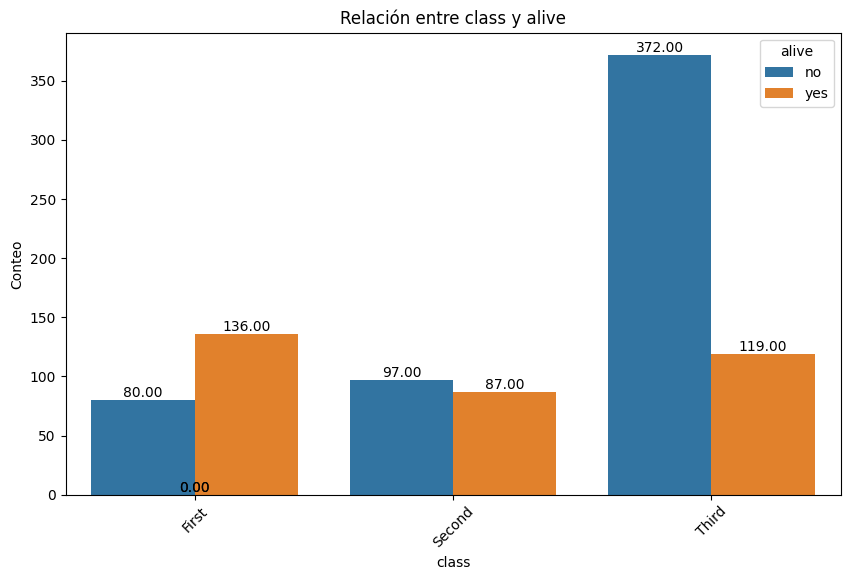

In [34]:
plot_categorical_relationship_fin(df,"class","alive", show_values= True)
# en terminos absolutos sobrevivió más gente de la primera clase 


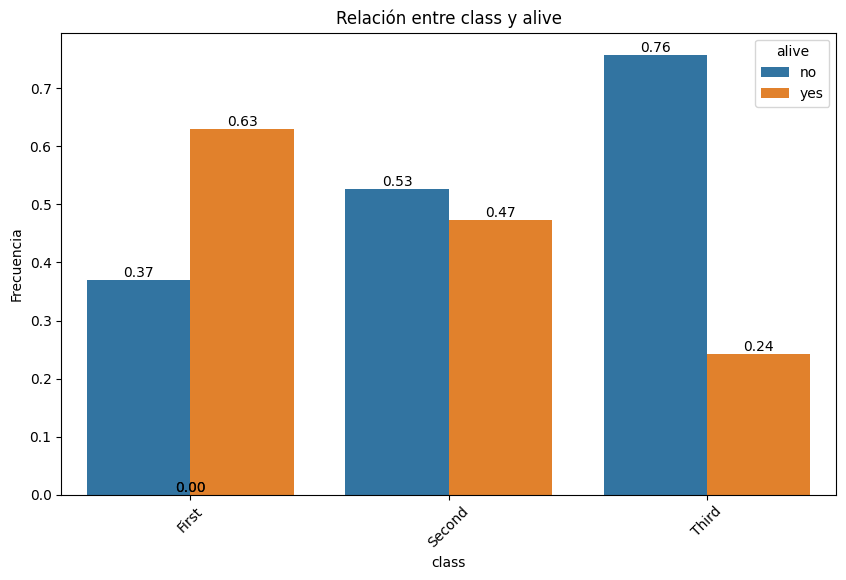

In [36]:
plot_categorical_relationship_fin(df,"class","alive", relative_freq=True,show_values= True)
# en terminos relativos también

In [38]:
tabla_contingencia = pd.crosstab(df['class'], df['alive'])
chi2, p, dof, expected = chi2_contingency(tabla_contingencia)

print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)
print("Grados de Libertad:", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)
# si hay un relacion estadísticamente significativa entre la clase y si sobrevivio o no 

Valor Chi-Cuadrado: 102.88898875696056
P-Value: 4.549251711298793e-23
Grados de Libertad: 2
Tabla de Frecuencias Esperadas:
 [[133.09090909  82.90909091]
 [113.37373737  70.62626263]
 [302.53535354 188.46464646]]


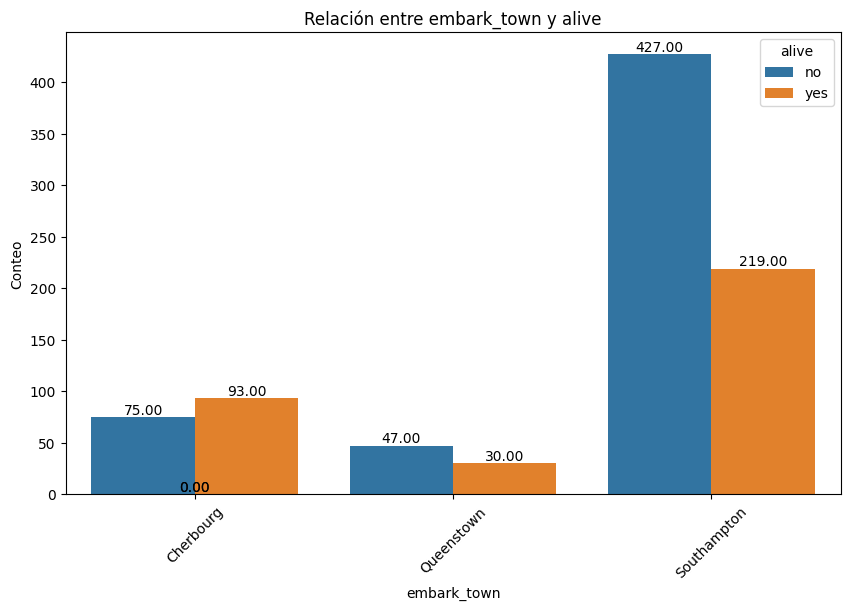

In [42]:
plot_categorical_relationship_fin(df,"embark_town","alive", show_values= True)
# en terminos absolutos sobrevivió más gente de sothampton 

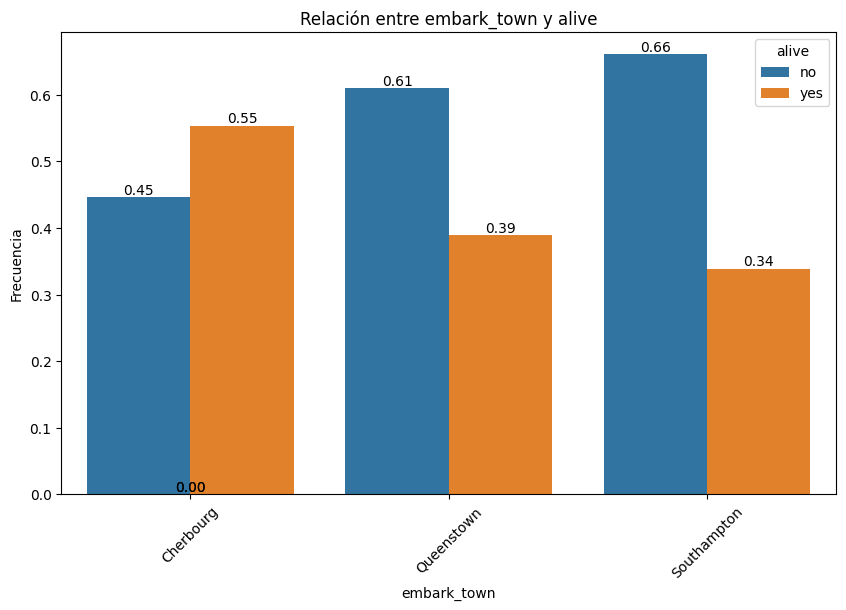

In [44]:
plot_categorical_relationship_fin(df,"embark_town","alive",relative_freq=True, show_values= True)
# en terminos relativos, cheesbourg fue en la que más sobrevivieron 

In [46]:
tabla_contingencia = pd.crosstab(df['embark_town'], df['alive'])
chi2, p, dof, expected = chi2_contingency(tabla_contingencia)

print("Valor Chi-Cuadrado:", chi2)
print("P-Value:", p)
print("Grados de Libertad:", dof)
print("Tabla de Frecuencias Esperadas:\n", expected)
# aunque es la más dévil de momento, si hay relación estadisticamente significativa entre la ciudad de embarque y la supervivencia

Valor Chi-Cuadrado: 25.964452881874784
P-Value: 2.3008626481449577e-06
Grados de Libertad: 2
Tabla de Frecuencias Esperadas:
 [[103.51515152  64.48484848]
 [ 47.44444444  29.55555556]
 [398.04040404 247.95959596]]


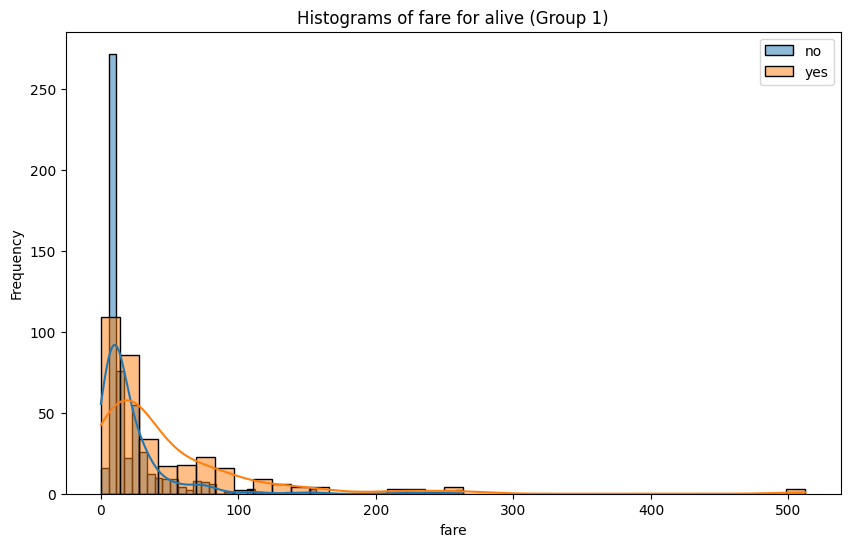

In [49]:
plot_grouped_histograms(df, cat_col="alive",num_col="fare", group_size= 2)
# parece que, para las personas que sobrevivieron, su distribución esta más inclinada hacia la derecha, es decir que pagaron más

In [50]:
from scipy.stats import mannwhitneyu

In [53]:
grupo_a = df.loc[df.alive == "yes"]["fare"]
grupo_b = df.loc[df.alive == "no"]["fare"]

u_stat, p_valor = mannwhitneyu(grupo_a, grupo_b)

print("Estadístico U:", u_stat)
print("Valor p:", p_valor)
# hay una relación estadísticamente significativa entre la tarifa y sobrevivir o no 

Estadístico U: 129951.5
Valor p: 4.553477179250237e-22


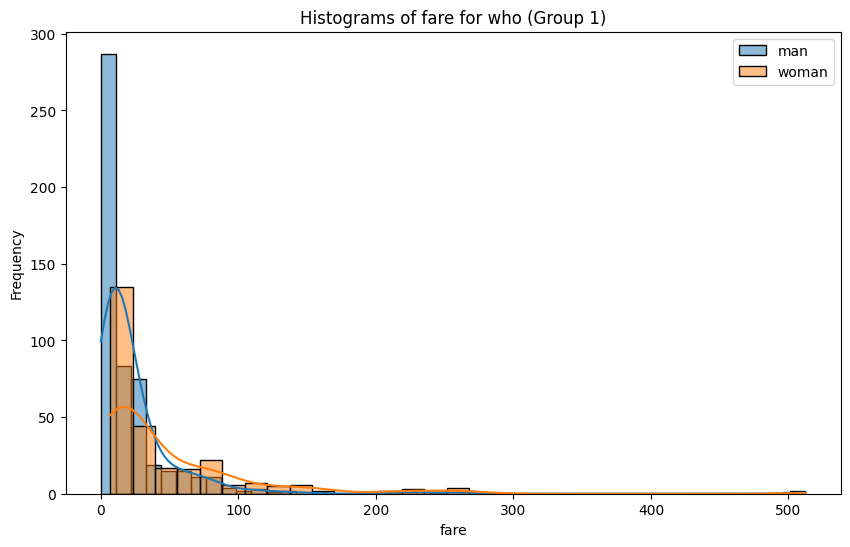

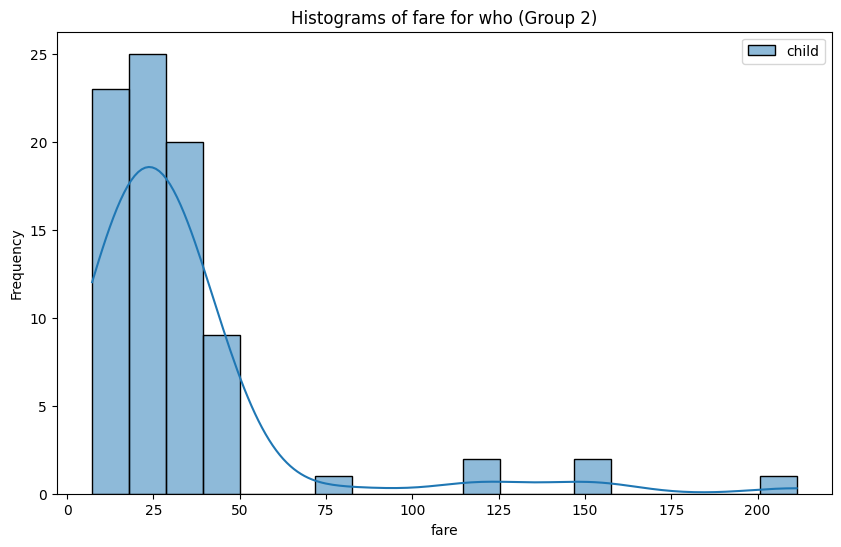

In [54]:
plot_grouped_histograms(df, cat_col="who",num_col="fare", group_size= 2)

In [57]:
# hay muchos hombres que no pagaron billete, lo más seguro es que fueran trabajadores del barco
df[df["fare"]==df["fare"].max()]
# hay tres personas que pagaron la tarifa máxima, los tres sobrevivieron, dos hombres y una mujer, de semejante edad, uno de ellos con miembros de la familia

,sex,age,fare,class,who,adult_male,embark_town,alive,alone,family_members,niño
258,female,35.0,512.3292,First,woman,False,Cherbourg,yes,True,0,False
679,male,36.0,512.3292,First,man,True,Cherbourg,yes,False,1,False
737,male,35.0,512.3292,First,man,True,Cherbourg,yes,True,0,False


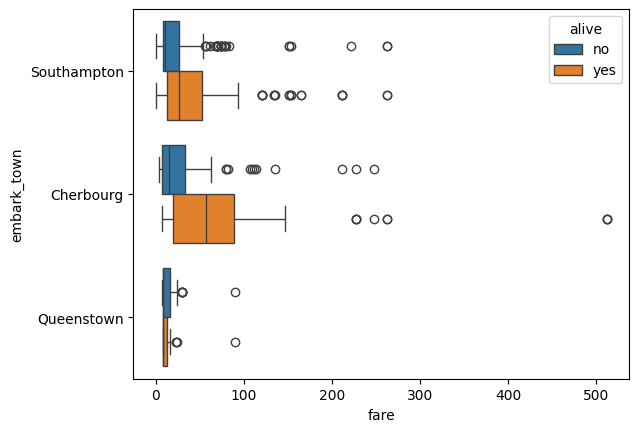

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df, x="fare", y="embark_town", hue="alive")
plt.show()
# parece que en cheesburg y southampton, las personas que mas pagaron son las que sobrevisieron en una mayor proporcion


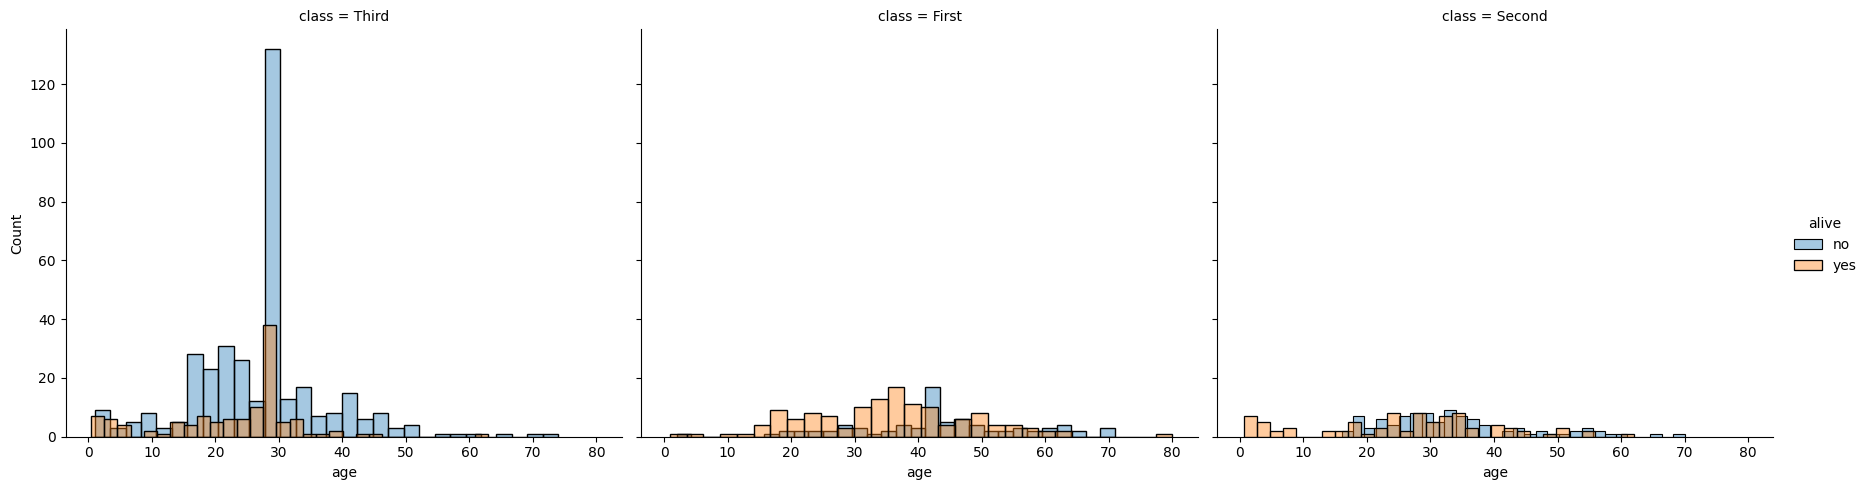

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.FacetGrid(df, col="class", hue="alive", height=5, aspect=1.2)
g.map(sns.histplot, "age", bins=30, kde=False, alpha=0.4)
g.add_legend()

plt.show()

# la diferencia de supervivencia por edad, se nota más en primera y segunda clase, donde los que más sobrevivieron son en general los más jovenes

In [77]:
col_directora = "alive"
col_1 = "fare"
col_2 = "age"
diccionario_multivariante = {}
for valor in df[col_directora].unique():
    diccionario_multivariante[valor] = df.loc[df[col_directora] == valor,[col_2,col_1]]

Respuesta no:


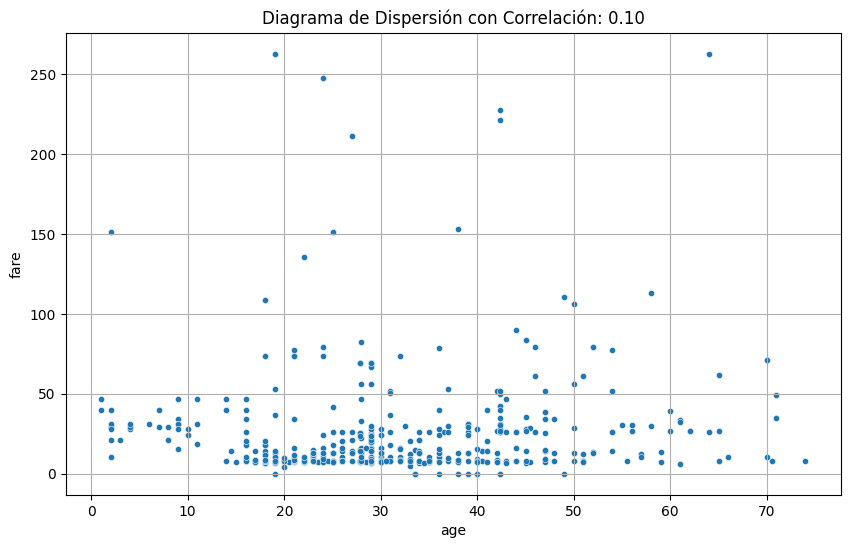

Respuesta yes:


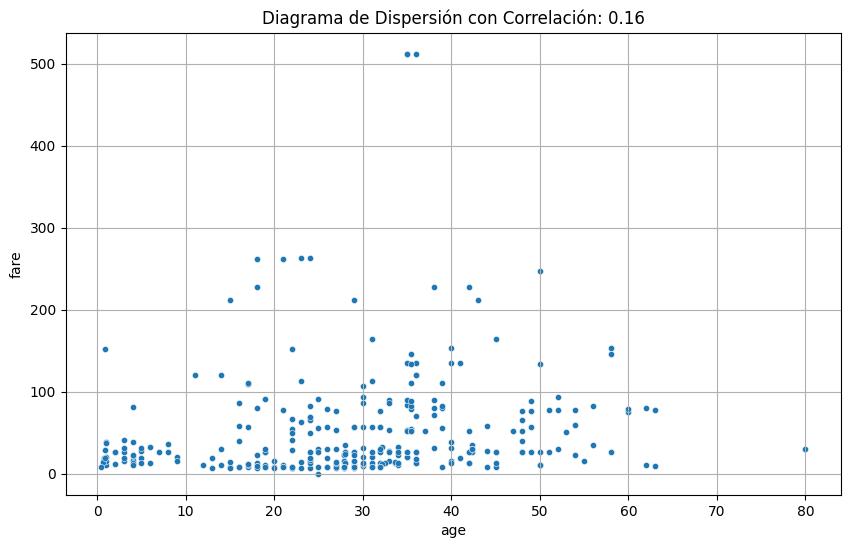

In [78]:
for valor,df_datos in diccionario_multivariante.items():
    print(f"Respuesta {valor}:")
    grafico_dispersion_con_correlacion(df_datos,col_2,col_1, tamano_puntos=20, mostrar_correlacion= True)

In [79]:
# no parece haber grandes diferencias entre la edad y la tarifa, tampoco entre la tarifa y sobrevivir, lo que más llama la 
# atención es que en el grupo que sobrevivió hay muchisima menos dispersión en la dimensión edad,
# lo que indica que las personas más mayores sobrevivieron en menor proporcion, mientras que los niño sobrevivieron en mayor proporición,
# independientemente de la tarifa

## #EXTRA: Viajes

El objetivo en este caso no es tanto hacer un montón de análisis sino de completar lo que quedó pendiente en el workout y de entender cómo de un dataset podemos obtener preguntas o hipótesis interesantes (si las hay)

### #EXTRA.1 

Carga el dataset de viajes del mes de junio. Repite el análisis bivariante entre las variables "Aircompany" e "Ingresos", mostrando previamente los viajes por compañía aérea. ¿Qué situación llamativa nos surgió? (Ten en cuenta que somos el departamenteo de DataScience de TabarAir)

In [ ]:
df_air_jun = pd.read_csv("./data/dataset_viajes_jun.csv")


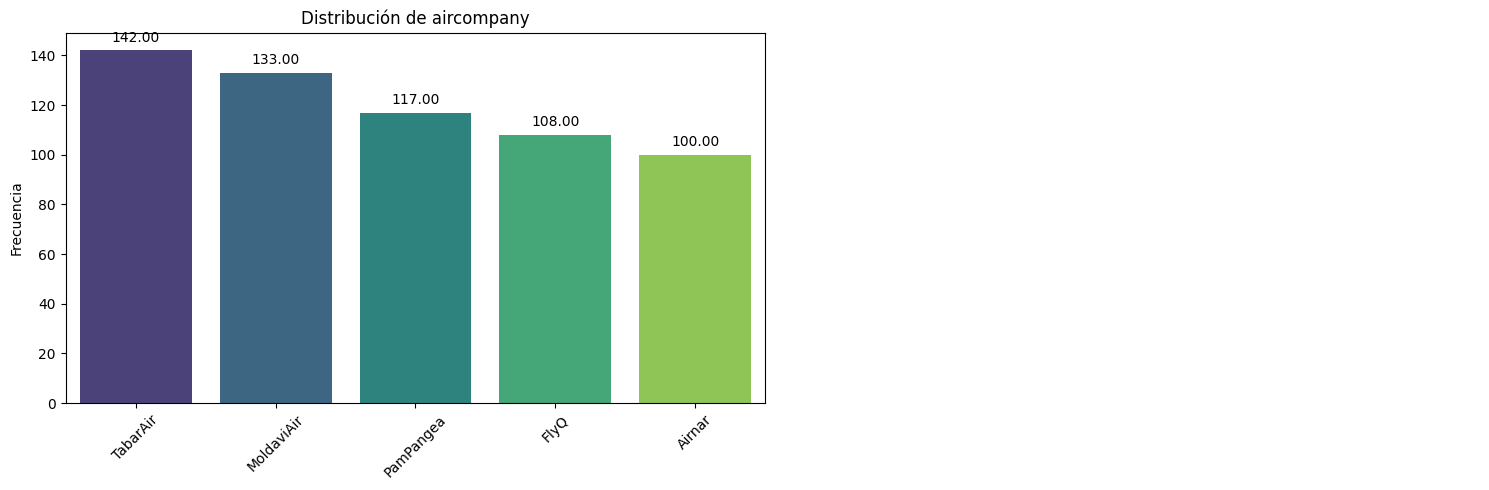

In [85]:
pinta_distribucion_categoricas(df_air_jun,["aircompany"],  mostrar_valores= True)

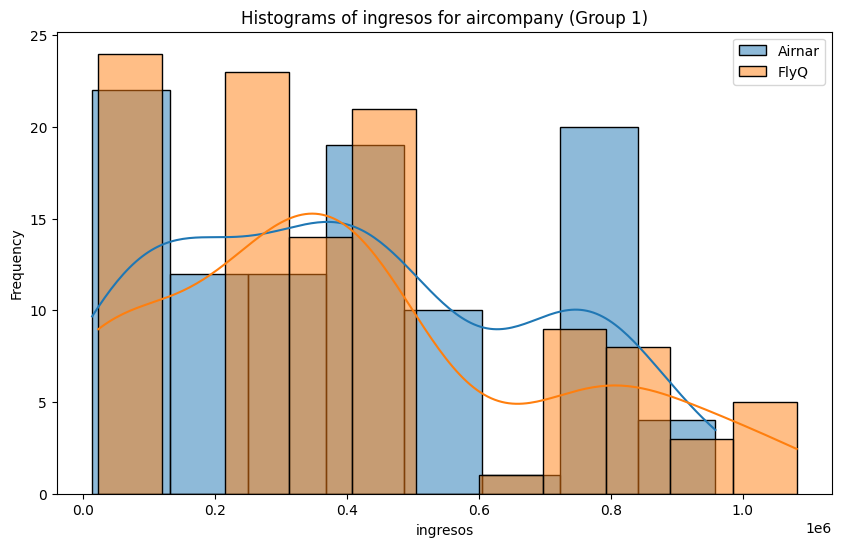

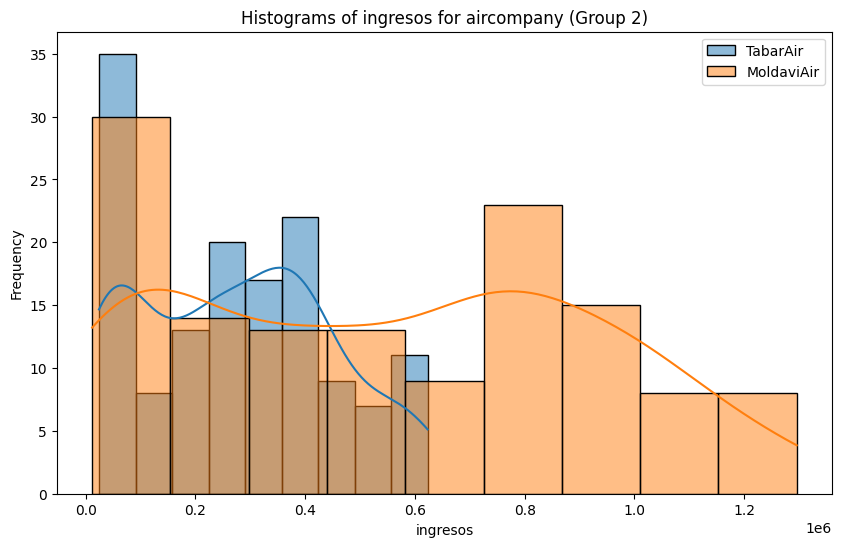

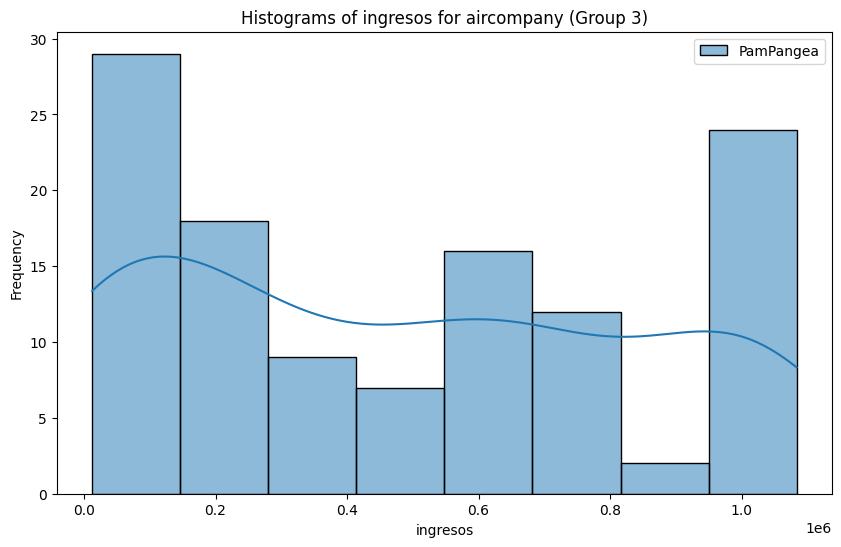

In [89]:
plot_grouped_histograms(df_air_jun, "aircompany","ingresos",group_size= 2)

In [90]:
# pampangea y airnar generan muchos ingresos en una gran cantidad de vuelos, mientras que nosotros no

### #EXTRA.2

Repite el análisis multivariante entre "ingresos","distancias" y "consumo_kg". ¿Qué veíamos que parecía también muy prometedor?

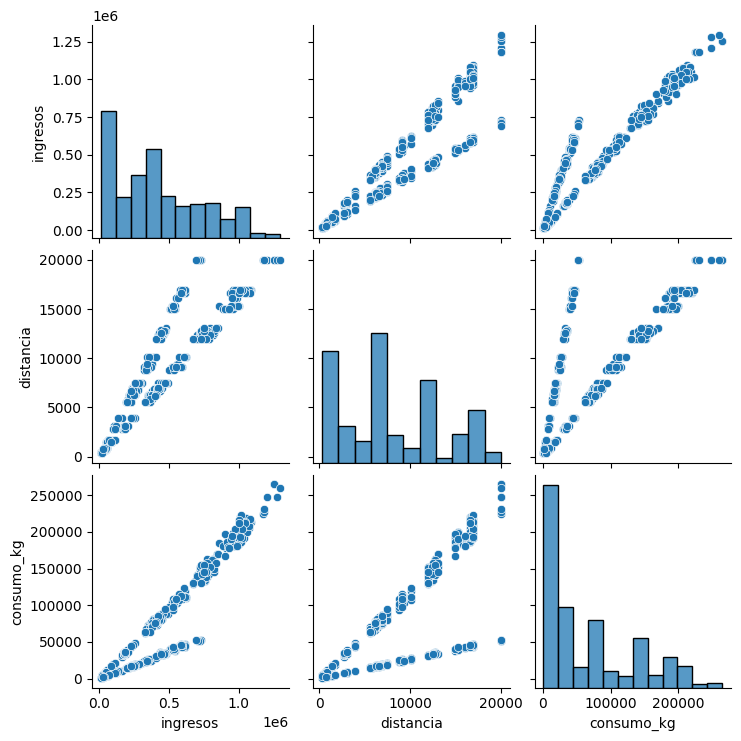

In [92]:
sns.pairplot(df_air_jun[["ingresos", "distancia", "consumo_kg"]])
plt.show()

In [93]:
# hay vuelos que con menos distancia y menos consumo consiguen mas ingresos

### #EXTRA.3

Crea una variable categorica "cat_vuelo" a partir de distancias, escoge los rangos de las categorías basándote en la distribución de valores de "distancia" (sugerencia entre 3 y 4 categorías). Extra: Reaiza ahora otra vez el análisis multivariante "cat_vuelo", "ingresos", "consumo_kg". ¿Ves algo diferente?

In [95]:
df_air_jun.distancia.describe()

count      600.000000
mean      8071.003333
std       5550.244086
min        344.000000
25%       3073.000000
50%       6877.000000
75%      12553.000000
max      20029.000000
Name: distancia, dtype: float64

In [97]:
df_air_jun["tipos_vuelo"] = pd.qcut(df_air_jun["distancia"], q=4, labels=["Q1","Q2","Q3","Q4"])


In [99]:
col_directora = "tipos_vuelo"
col_1 = "consumo_kg"
col_2 = "ingresos"
diccionario_multivariante = {}
for valor in df_air_jun[col_directora].unique():
    diccionario_multivariante[valor] = df_air_jun.loc[df_air_jun[col_directora] == valor,[col_2,col_1]]

Respuesta Q1:


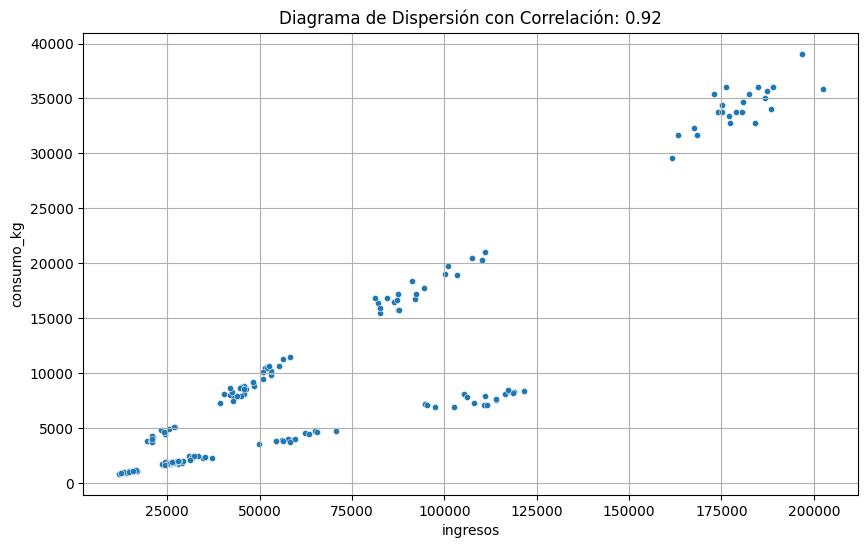

Respuesta Q4:


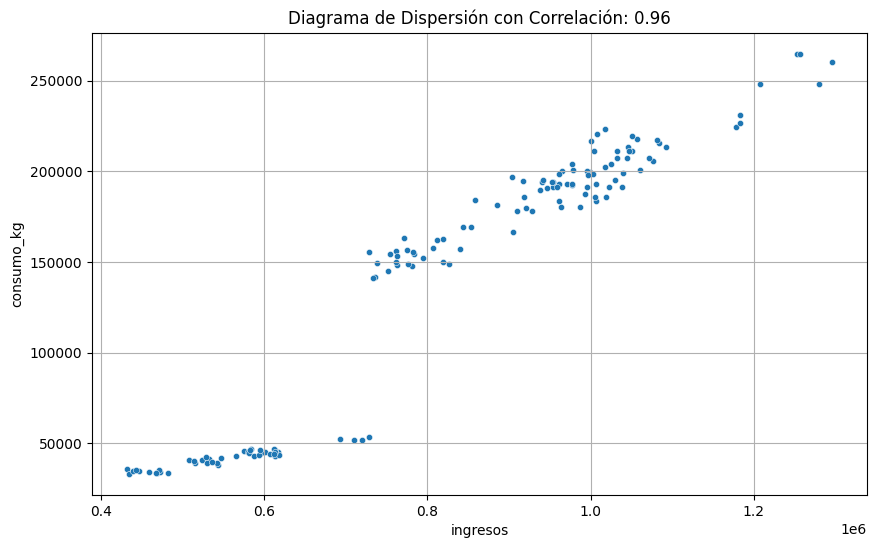

Respuesta Q3:


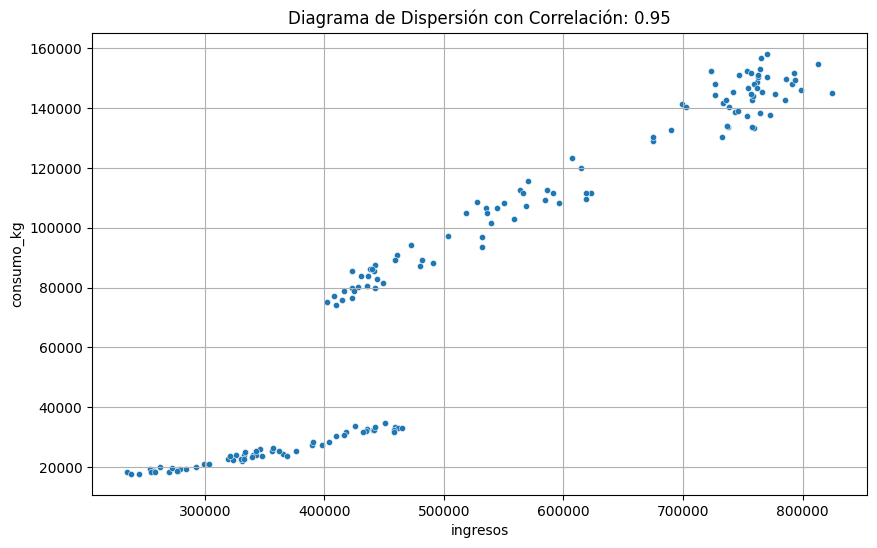

Respuesta Q2:


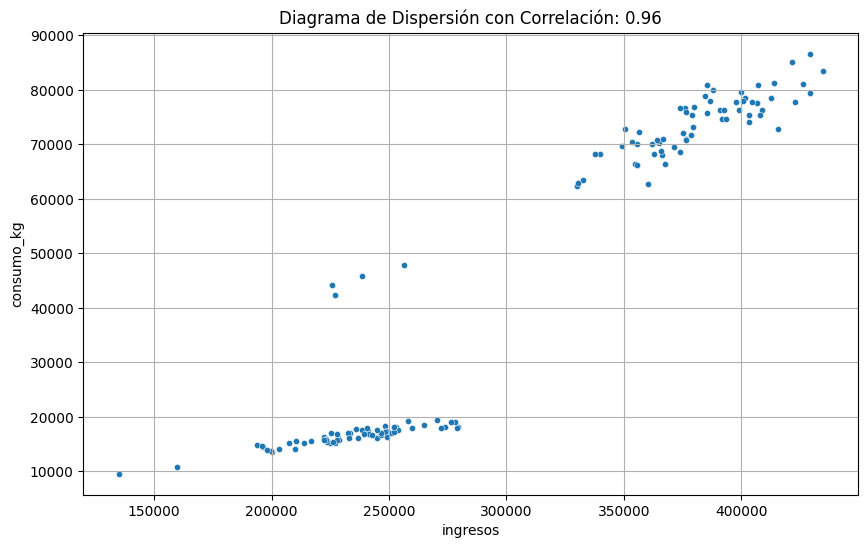

In [ ]:
for valor,df_datos in diccionario_multivariante.items():
    print(f"Respuesta {valor}:")
    grafico_dispersion_con_correlacion(df_datos,col_2,col_1, tamano_puntos=20, mostrar_correlacion= True)

In [102]:
# independientemente de la distancia, los que más consumen son los que más ingresos generan, aun así, sigue habiendo una linea inferior, en la que los 
#vuelos generan lo mismo que otros con mayor gasto en combustible, sosbretodo en el q1 y q2, creo que el tipo de avión y la cantidad de gente dentro
# del mismo juegan un papel muy importante